In [ ]:
%config InlineBackend.figure_format = 'svg' # Stops error bars being offset in plots

In [1]:
import numpy as np
from sim_library.constants import k_eff, dR, m, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom
from sim_library.data_io import load_p_dists

### Single atom simulation

##### Imported pulse sequence (RR3)

In [2]:
### Simulate RR3 pulse sequence ###

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*1e7
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set time steps per pulse
time_steps = 1

# Import pulse sequence from library (sequences.py)
RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)
RR3.build_seq() # populates parameter arrays in PulseSequence object

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -2
p_max = 2
basis = np.arange(p_min, p_max + 1)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
init_p = 0 # integer p in unit of hbar*k
initial_state[init_p - p_min] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Set doppler shift
atom_veloc = 0 # Stationary

# Simulate
wave_func, times = simulate_pulses_single_atom(pulse_seq= RR3, basis= basis, initial_state= initial_state, d_shift= k_eff*atom_veloc)

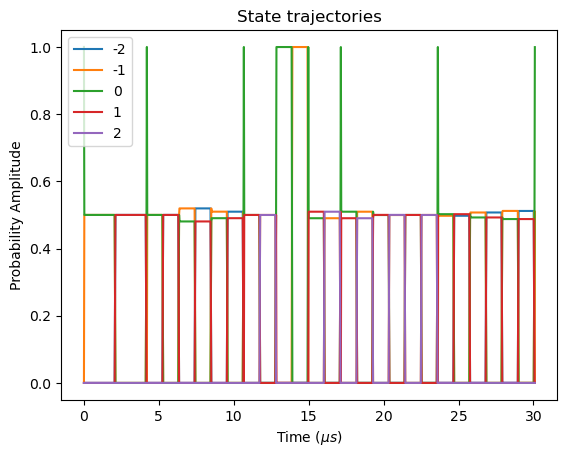

In [3]:
### Plot state amplitudes vs time ###

fig, ax = plt.subplots()
plot_state_trajectories(ax = ax, wavefunc=wave_func, time_array=times, basis=basis)

##### Custom pulse sequence (Mach-Zehnder)

In [4]:
### Build pulse sequence ###

rabi_freq = 2*pi*1e6
rabi_time = 2*pi/rabi_freq 

time_steps = 10

mach_zehnder = PulseSequence()

beamsplitter = UpPulse(laser_det=np.full(time_steps,dR), phase=np.full(time_steps,0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
mirror = UpPulse(laser_det=np.full(time_steps,dR), phase=np.full(time_steps,0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)

free_time = rabi_time*15
free = FreeEvolution(laser_det=np.full(time_steps,0), duration=free_time/2)

mach_zehnder.add_pulses([
    beamsplitter,
    free,
    mirror,
    free,
    beamsplitter
])

mach_zehnder.build_seq()

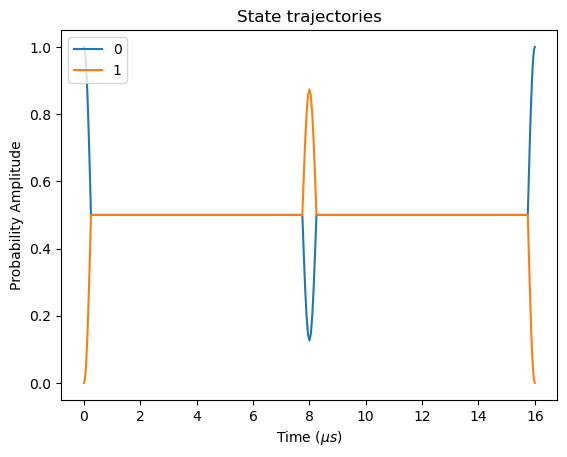

In [5]:
### Simulate and plot state trajectories ###

# Just |g> and |e>
p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
init_p = 0 
initial_state[init_p - p_min] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

wave_func, times = simulate_pulses_single_atom(pulse_seq= mach_zehnder, basis= basis, initial_state= initial_state, d_shift= 0)

fig, ax = plt.subplots()
plot_state_trajectories(ax=ax, wavefunc=wave_func, time_array=times, basis=basis)

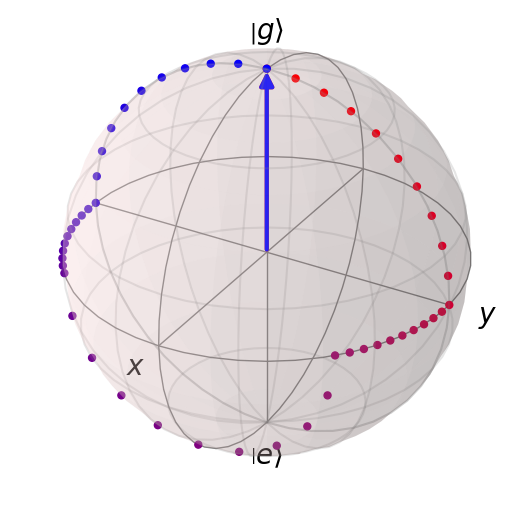

In [6]:
### Plot Bloch sphere trajectory ###
_ = plot_bloch(wave_func= wave_func, labels=['$\\left| g\\right\\rangle$', '$\\left| e\\right\\rangle$'], show=True)

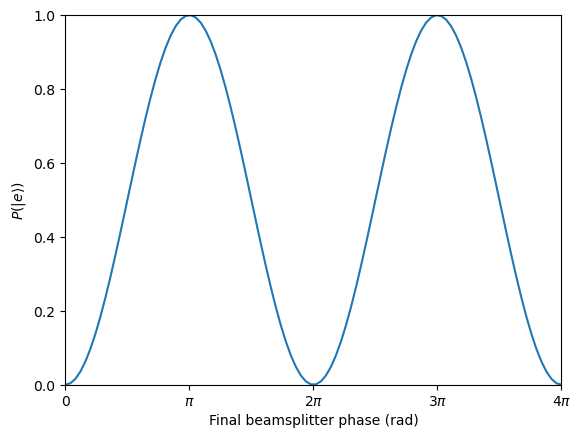

In [7]:
### Vary final beamsplitter phase and plot interference pattern ###

rabi_freq = 2*pi*1e6
rabi_time = 2*pi/rabi_freq 

time_steps = 1

phases = np.linspace(0, 2*2*pi, 100) # x axis
prob_amps = np.zeros(len(phases)) # y axis

# Just |g> and |e>
p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
init_p = 0 
initial_state[init_p - p_min] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Define pulses
beamsplitter1 = UpPulse(laser_det=np.full(time_steps,dR), phase=np.full(time_steps,0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
mirror = UpPulse(laser_det=np.full(time_steps,dR), phase=np.full(time_steps,0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
free_time = rabi_time*10
free = FreeEvolution(laser_det=np.full(time_steps,dR), duration=free_time/2)

# Iterate through phases
for i, phase in enumerate(phases):
    mach_zehnder = PulseSequence()
    beamsplitter2 = UpPulse(laser_det=np.full(time_steps,dR), phase=np.full(time_steps,phase), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
    mach_zehnder.add_pulses([
        beamsplitter1,
        free,
        mirror,
        free,
        beamsplitter2
    ])
    mach_zehnder.build_seq()
    
    wave_func, _ = simulate_pulses_single_atom(pulse_seq= mach_zehnder, basis= basis, initial_state= initial_state, d_shift= 0)
    
    # Record final amplitude of |e>
    prob_amps[i] = np.abs(wave_func[-1,1])**2

# Plot |e> probability amplitude against phase
fig, ax = plt.subplots()
ax.plot(phases,prob_amps)
ax.set_ylim(0,1)
ax.set_xlim(phases[0],phases[-1])
ax.set_xticks(ticks = np.arange(0,5)*pi, labels=[0,r'$\pi$',r'$2\pi$',r'$3\pi$',r'$4\pi$'])
ax.set_xlabel('Final beamsplitter phase (rad)')
ax.set_ylabel(r'$P(|e\rangle)$');


### Atomic ensemble simulation

##### Simulate pulse sequence

In [8]:
### Simulate pulse sequence on atomic ensemble

# Set ensemble parameters
N = 50000
initial_temp = 15e-6

rabi_freq = 2*pi*5e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)
RR3.build_seq()

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[16] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

# Intensity noise
# Dimensionless distribution centred on 1 - multiplies by central rabi frequency
# Use np.full(N,1) for flat profile
beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N) 

# Simulate
mom_dist, state_fractions, _ , _, _ = simulate_pulses_p_dist(pulse_seq=RR3, Temp=initial_temp, no_atoms=N, basis=basis, initial_state=initial_state, beam_profile=beam_profile)

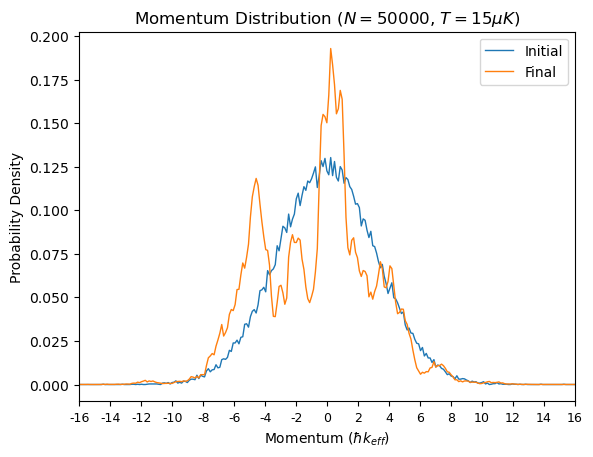

In [9]:
### Plot initial and final momentum distribution ###

fig, ax = plt.subplots()
plot_hist(ax=ax, mom_vals=mom_dist/(hbar*k_eff), fracs=state_fractions, n_bins=500, basis=basis, n_atoms=N, temp=initial_temp)

##### Simulate cooling sequence

In [ ]:
### Simulate many cycles of a pulse sequence with optical pumping after each one ###

# Set ensemble parameters
N = 10000
initial_temp = 15e-6

rabi_freq = 2*pi*5e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)
RR3.build_seq()

# Cooling parameters
cycles = 8
pumping_route = 'f3' # optical pumping via either F'=2 ('f2') or F'=3 ('f3')

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[16] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

# Intensity noise
beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N) 

# Simulate cooling sequence
moms_list, fracs_list, _ = simulate_alg_cooling(basis=basis, sequence=RR3, n_atoms=N, temp=initial_temp, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route=pumping_route,
                                                        # save_dir='data/algorithmic cooling/'
                                                        )

In [7]:
# Convert to units of hbark
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

# Finds highest/lowest momentum values across entire data
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

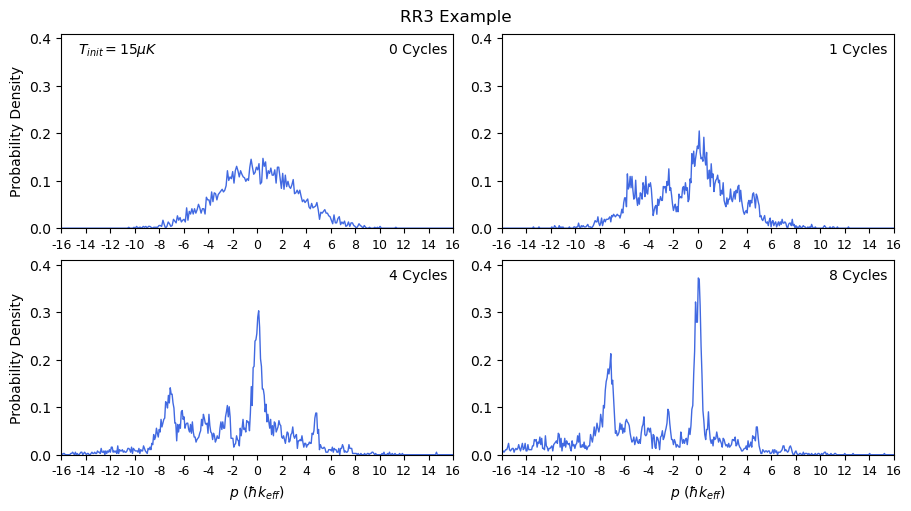

In [8]:
### Plot at different cycles ###

# For labelling
cycles_list = np.array([0,1,4,8])
index_list = np.array([0,2,8,16])
# For n cycles there will be 2n+1 'frames'
# Index of nth cycles will therefore be 2n

# No. bins for each panel
bins_list = np.full(4, 1000)
bins_list[0] = 700 

# Plot 2x2 panels
plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bins_list=bins_list, title='RR3 Example', temp=initial_temp, show=False, datarange=global_range,
                     #   save_dir="plots/histograms/RR3_example.png"
                       )

##### Simulate cooling sequence (custom initial distribution)

In [4]:
### Simulate many cycles of a pulse sequence with optical pumping after each one ###

# Set ensemble parameters
N = 10000
# Initial flat momentum distribution
p_dist = np.random.uniform(-32,32, size=N)*hbar*k_eff

rabi_freq = 2*pi*5e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)
RR3.build_seq()

# Cooling parameters
cycles = 8
pumping_route = 'f3' # optical pumping via either F'=2 ('f2') or F'=3 ('f3')

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[16] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

# Intensity noise
beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N) 

# Simulate cooling sequence
moms_list, fracs_list = simulate_alg_cooling_custom(basis=basis, sequence=RR3, p_dist=p_dist, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3',
                                                        # save_dir='data/algorithmic cooling/flat',
                                                        )

In [5]:
# Convert to units of hbark
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

# Finds highest/lowest momentum values across entire data
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

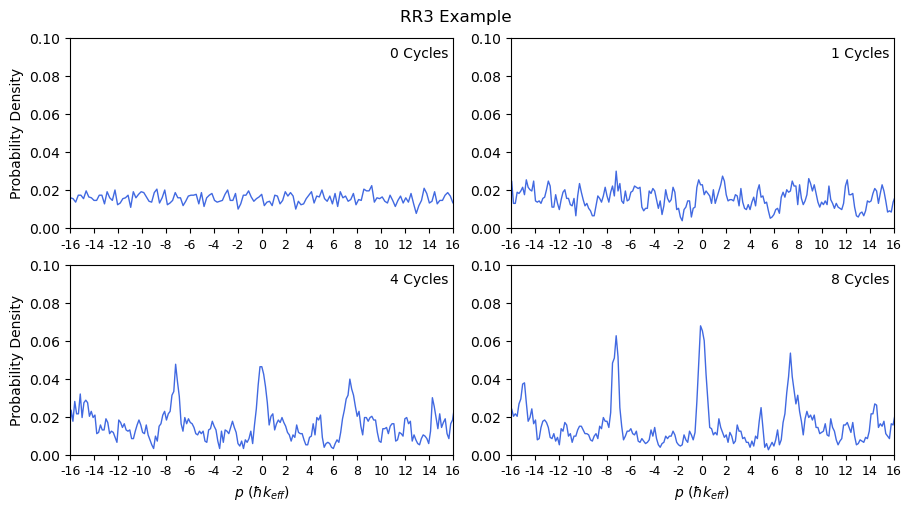

In [ ]:
### Plot at different cycles ###

# For labelling
cycles_list = np.array([0,1,4,8])
index_list = np.array([0,2,8,16])
# For n cycles there will be 2n+1 'frames'
# Index of nth cycles will therefore be 2n

# No. bins for each panel
bins_list = np.full(4, 1000)
bins_list[0] = 700 

# Plot 2x2 panels
plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bins_list=bins_list, title='RR3 Example', show=False, datarange=global_range,
                     ylim = 0.1,
                     autoyticks=True, # use if max height < 0.1
                     #   save_dir="plots/histograms/RR3_example.png"
                       )

##### Loading from file

In [10]:
path = Path("data/algorithmic cooling/RR3_example.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

# Convert to units of hbark
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

# Finds highest/lowest momentum values across entire data
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

(10000,)


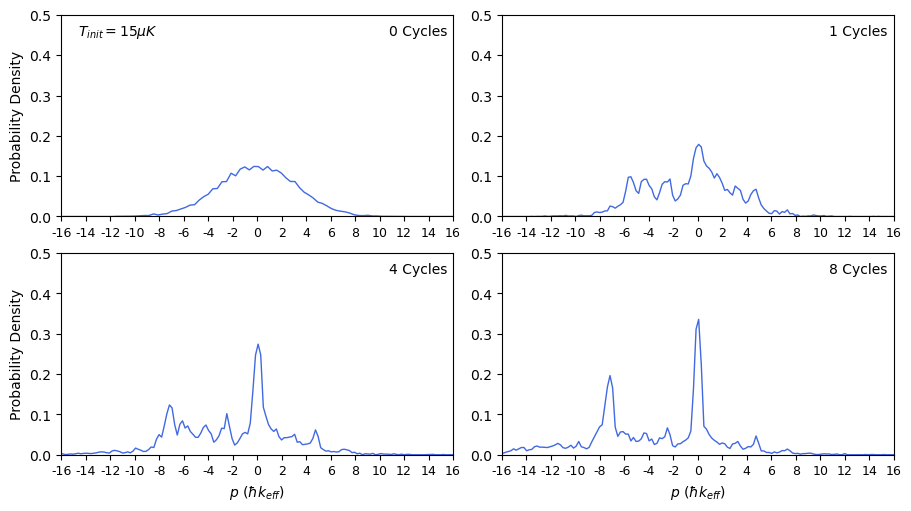

In [17]:
cycles_list = np.array([0,1,4,8])
index_list = np.array([0,2,8,16])
bins_list = np.full(4,350)
bins_list[0] = 200

plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bins_list=bins_list, temp=Temp, show=False, datarange=global_range,
                      ylim=0.5,
                       )

print(np.shape(moms_list[2]))

##### Gaussian fit (efficiency and temperature calculation)

In [2]:
# Load in data
path = Path("data/algorithmic cooling/RR3_example.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

# Convert to units of hbark
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

# Finds highest/lowest momentum values across entire data
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

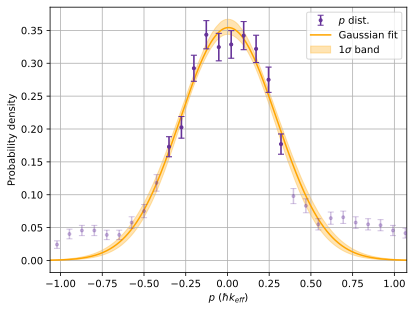

Efficiency: 25.712 +/- 0.0096385 %
Temperature: 0.12421 +/- 0.013926 muK
Center: 0.0059845 +/- 0.0097278 hbark


In [10]:
### Fitting gaussian with auto peak detection ###

# Width of domain relative to width of truncated data
# Default is 1
xscale = 3

# Fraction of peak height used to truncate data
# Default is 0.5 (i.e. FWHM)
threshold = 0.5

amp, T, shift, errs = fit_gaussian(moms_list[-1], fracs=fracs_list[-1], range = global_range, nbins=1000, 
                                   xscale=xscale,
                                   threshold=threshold,
                                   plot=True, 
                                   print_vals=True,
                                   joindata=False
                                    )

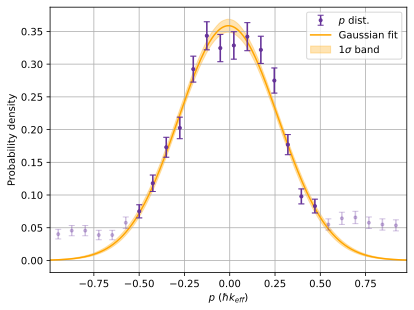

Efficiency: 24.752 +/- 0.0054381 %
Temperature: 0.11227 +/- 0.0061315 muK
Center: -0.0070724 +/- 0.00665 hbark


In [ ]:
### Fitting gaussian with manual data truncation ###

# Domain (in units of hbark) in which data is fitted
p_low = -0.5
p_high = 0.5

amp, T, shift, errs = fit_gaussian_custom(moms_list[-1], fracs=fracs_list[-1], range = global_range, nbins=1000,
                                   trunc_lims=(p_low,p_high), 
                                   xscale=2,
                                   plot=True, 
                                   print_vals=True,
                                   joindata=False
                                    )

### Misc

##### Generate gif

In [ ]:
### Simulate single atom and ensemble ###

rabi_freq = 2*pi*1e7
rabi_time = 2*pi/rabi_freq # 2pi pulse time

time_steps = 10

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)
RR3.build_seq() # populates parameter arrays in PulseSequence object

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
init_p = 4 # integer p in unit of hbar*k
initial_state[init_p - p_min] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

wave_func, times = simulate_pulses_single_atom(pulse_seq= RR3, basis= basis, initial_state= initial_state, d_shift= 0)
prob_amps = np.abs(wave_func)**2

N = 20000
initial_temp = 15e-6

beam_profile = np.full(N,1)
# beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N) 

mom_dist, state_fractions, _ , _, _ = simulate_pulses_p_dist(pulse_seq=RR3, Temp=initial_temp, no_atoms=N, basis=basis, initial_state=initial_state, beam_profile=beam_profile)

200 frames


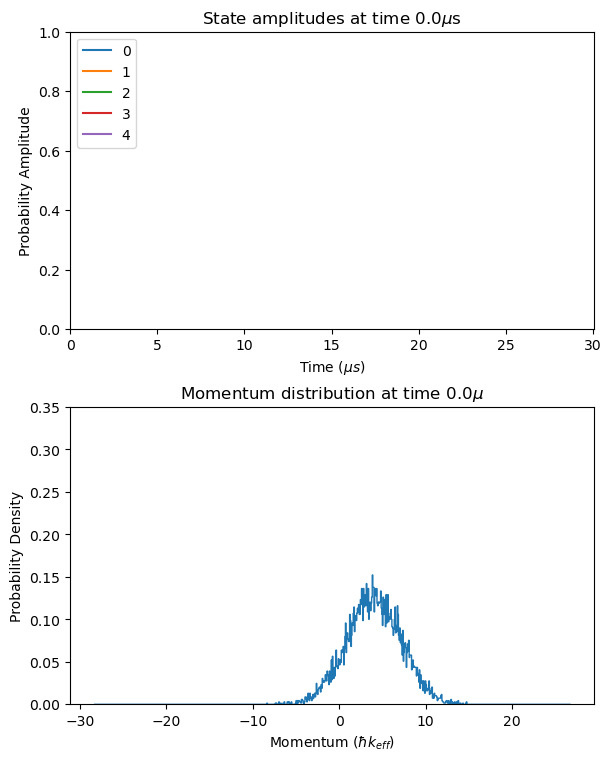

In [ ]:
### Generate gif ###

# Truncate basis for plotting
p_low = 0
p_high = 4

save_gif(filename='plots/gifs/example_RR3.gif', mom_vals=mom_dist/(hbar*k_eff), fracs=state_fractions, n_bins=800, wavefunc=prob_amps[:,p_low-p_min:p_high+1-p_min], times=times, basis=basis[p_low-p_min:p_high+1-p_min], frame_interval=50, pause_time=3000, mom_ylim=0.35)